Week-1 Internship Program House Price Prediction Model.

Importing all the required Python Libraries.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

                                **TASK-1 DATA LOADING AND EXPLORATION**

Reading the CSV File.

In [3]:
df=pd.read_csv("/content/Housing.csv")

Displaying the Top 10 Rows.

In [4]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


Display the Total number of rows nd columns.

In [5]:
df.count()

,0
price,545
area,545
bedrooms,545
bathrooms,545
stories,545
mainroad,545
guestroom,545
basement,545
hotwaterheating,545
airconditioning,545


Identifying the Target columns and Features.

In [6]:
df["target"]=df["price"]
df=df.drop("price",axis=1)

                                 **TASK-2 DATA CLEANING**

Checking is there any Missing values in each column.

In [7]:
df.isnull().sum()

,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0
parking,0


Clearly,there is no null values present in each columns.

                       DATA CLEANING

Finding whether there exist any duplicates.

In [8]:
df.duplicated().any()

np.False_

In [9]:
df.duplicated().sum()

np.int64(0)

Clearly,there is no dulicate rows available in the dataset.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   area              545 non-null    int64 
 1   bedrooms          545 non-null    int64 
 2   bathrooms         545 non-null    int64 
 3   stories           545 non-null    int64 
 4   mainroad          545 non-null    object
 5   guestroom         545 non-null    object
 6   basement          545 non-null    object
 7   hotwaterheating   545 non-null    object
 8   airconditioning   545 non-null    object
 9   parking           545 non-null    int64 
 10  prefarea          545 non-null    object
 11  furnishingstatus  545 non-null    object
 12  target            545 non-null    int64 
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


Encoding all categorical values into 0's and 1's.

Checking each columns unique values.

In [11]:
a=df["mainroad"].unique()
print(a)
df["mainroad"]=df["mainroad"].map({'yes':1,'no':0})
df["mainroad"]

['yes' 'no']


,mainroad
0,1
1,1
2,1
3,1
4,1
...,...
540,1
541,0
542,1
543,0


In [12]:
df["guestroom"].unique()

array(['no', 'yes'], dtype=object)

Checking whether all the values in guestroom column is of string.

In [13]:
print(df["guestroom"].apply(type).value_counts())

guestroom
<class 'str'>    545
Name: count, dtype: int64


In [14]:
print(df["guestroom"].dtype)
print(df["guestroom"].unique())

df["guestroom"] = df["guestroom"].map({'yes': 1, 'no': 0})

print(df["guestroom"].dtype)
print(df["guestroom"].unique())


object
['no' 'yes']
int64
[0 1]


In [15]:
df["guestroom"]

,guestroom
0,0
1,0
2,0
3,0
4,1
...,...
540,0
541,0
542,0
543,0


In [16]:
df["basement"].unique()

array(['no', 'yes'], dtype=object)

In [17]:
df["basement"]=df["basement"].map({'yes':1,'no':0})

In [18]:
df["hotwaterheating"].unique()

array(['no', 'yes'], dtype=object)

In [19]:
df["hotwaterheating"]=df["hotwaterheating"].map({'yes':1,'no':0})

In [20]:
df["hotwaterheating"].unique()

array([0, 1])

In [21]:
df["airconditioning"].unique()
df["airconditioning"]=df["airconditioning"].map({'yes':1,'no':0})
df["airconditioning"].unique()

array([1, 0])

In [22]:
df["prefarea"].unique()

array(['yes', 'no'], dtype=object)

In [23]:
df["prefarea"]=df["prefarea"].map({'yes':1,'no':0})
df["prefarea"].unique()

array([1, 0])

using one hot encoding for the categorical variable furnishingstatus

In [24]:
df=pd.get_dummies(df,columns=["furnishingstatus"],drop_first=True)
df

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,target,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,13300000,False,False
1,8960,4,4,4,1,0,0,0,1,3,0,12250000,False,False
2,9960,3,2,2,1,0,1,0,0,2,1,12250000,True,False
3,7500,4,2,2,1,0,1,0,1,3,1,12215000,False,False
4,7420,4,1,2,1,1,1,0,1,2,0,11410000,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,1820000,False,True
541,2400,3,1,1,0,0,0,0,0,0,0,1767150,True,False
542,3620,2,1,1,1,0,0,0,0,0,0,1750000,False,True
543,2910,3,1,1,0,0,0,0,0,0,0,1750000,False,False


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   area                             545 non-null    int64
 1   bedrooms                         545 non-null    int64
 2   bathrooms                        545 non-null    int64
 3   stories                          545 non-null    int64
 4   mainroad                         545 non-null    int64
 5   guestroom                        545 non-null    int64
 6   basement                         545 non-null    int64
 7   hotwaterheating                  545 non-null    int64
 8   airconditioning                  545 non-null    int64
 9   parking                          545 non-null    int64
 10  prefarea                         545 non-null    int64
 11  target                           545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    b

Let's check whether the column stories have influence with the target variable

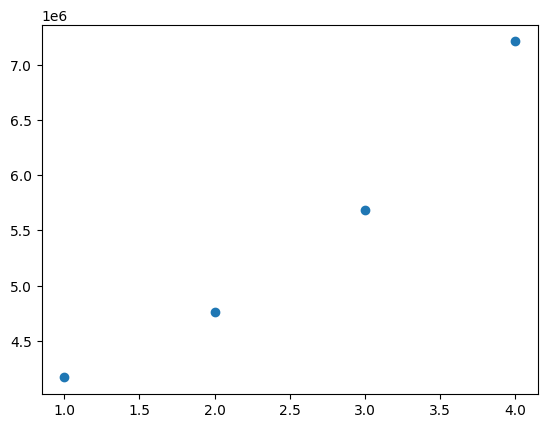

In [26]:
avg_target = df.groupby("stories")["target"].mean()
plt.scatter(x=avg_target.index,y=avg_target.values)

<BarContainer object of 6 artists>

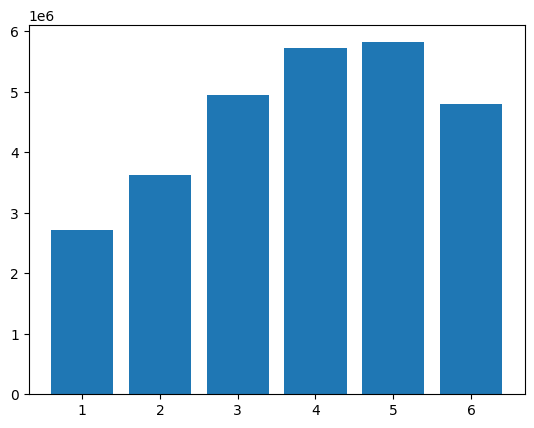

In [27]:
heater=df.groupby("bedrooms")["target"].mean()
plt.bar(heater.index,heater.values)

<BarContainer object of 4 artists>

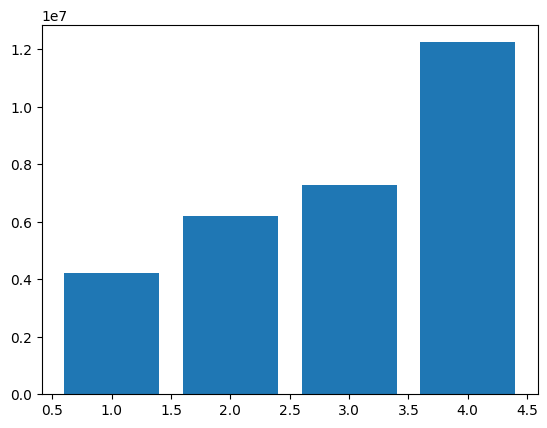

In [28]:
bathroom=df.groupby("bathrooms")["target"].mean()
plt.bar(bathroom.index,bathroom.values)

<BarContainer object of 2 artists>

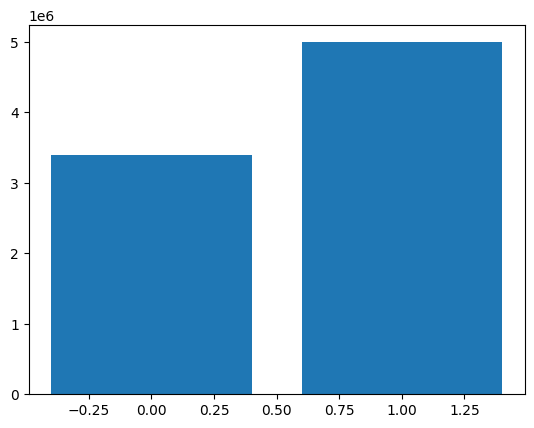

In [29]:
mainroad=df.groupby("mainroad")["target"].mean()
plt.bar(mainroad.index,mainroad.values)

<BarContainer object of 2 artists>

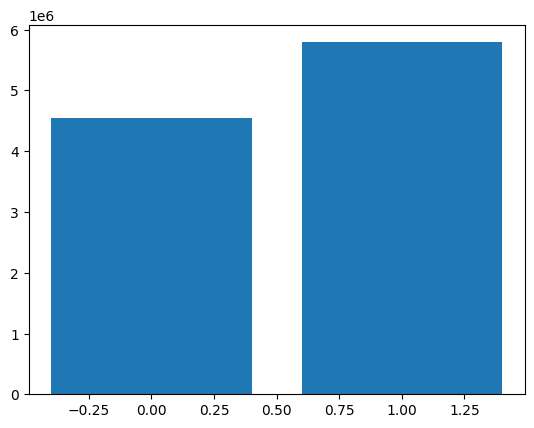

In [30]:
guestroom=df.groupby("guestroom")["target"].mean()
plt.bar(guestroom.index,guestroom.values)

<BarContainer object of 2 artists>

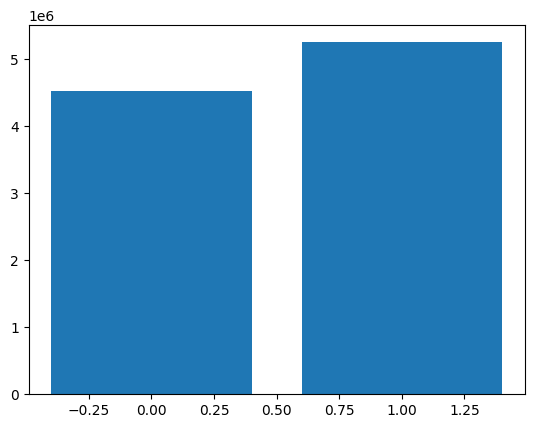

In [31]:
basement=df.groupby("basement")["target"].mean()
plt.bar(basement.index,basement.values)

<BarContainer object of 2 artists>

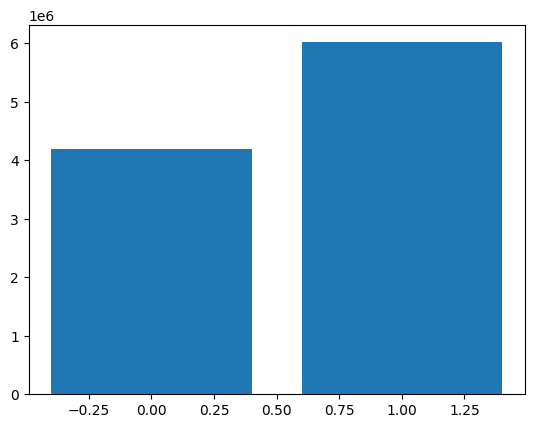

In [32]:
air_cond=df.groupby("airconditioning")["target"].mean()
plt.bar(air_cond.index,air_cond.values)

<BarContainer object of 4 artists>

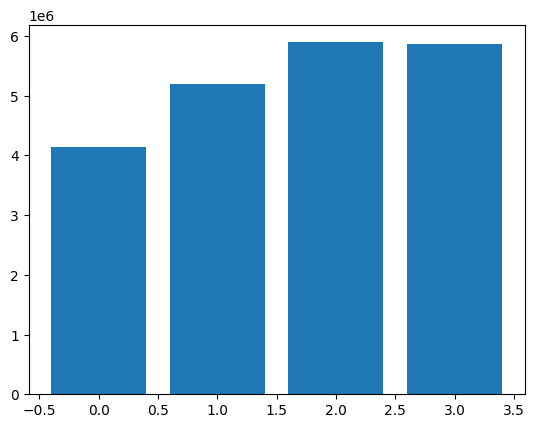

In [33]:
parking=df.groupby("parking")["target"].mean()
plt.bar(parking.index,parking.values)

<BarContainer object of 2 artists>

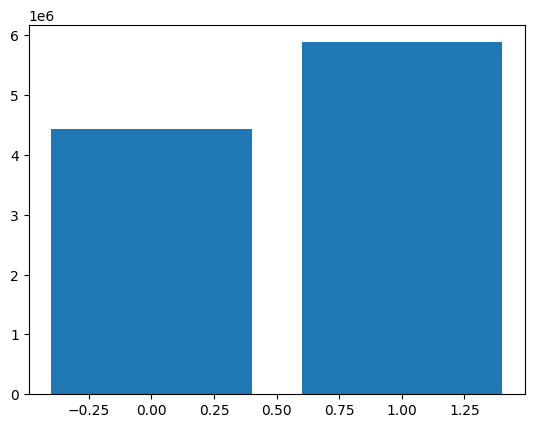

In [34]:
prefarea=df.groupby("prefarea")["target"].mean()
plt.bar(prefarea.index,prefarea.values)
#

Evalauting the correlation of all features with the target

In [35]:
corr_matrix=df.corrwith(df["target"])
print(corr_matrix)

area                               0.535997
bedrooms                           0.366494
bathrooms                          0.517545
stories                            0.420712
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
airconditioning                    0.452954
parking                            0.384394
prefarea                           0.329777
target                             1.000000
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
dtype: float64


MODEL BUILDING

In [36]:
x=df.drop("target",axis=1)
y=df["target"]

                               **TASK-3 MODEL BUILDING **

Splitting the dataset into training and testing dataset.

In [37]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

Linear Regression

In [52]:
from sklearn.linear_model import LinearRegression
linear_model=LinearRegression()
linear_model.fit(x_train,y_train)

LinearRegression()

Testing the model by predicting with the test dataset

In [53]:
y_predict=linear_model.predict(x_test)
from sklearn.metrics import r2_score
print("R2SCORE:",r2_score(y_test,y_predict))
from sklearn.metrics import mean_absolute_error
print("MAE:",mean_absolute_error(y_test,y_predict))
from sklearn.metrics import mean_squared_error
print("MSE:",mean_squared_error(y_test,y_predict))
rmse=np.sqrt(mean_squared_error(y_test,y_predict))
print("RMSE:",rmse)

R2SCORE: 0.6529242642153185
MAE: 970043.4039201637
MSE: 1754318687330.6633
RMSE: 1324506.9600914384


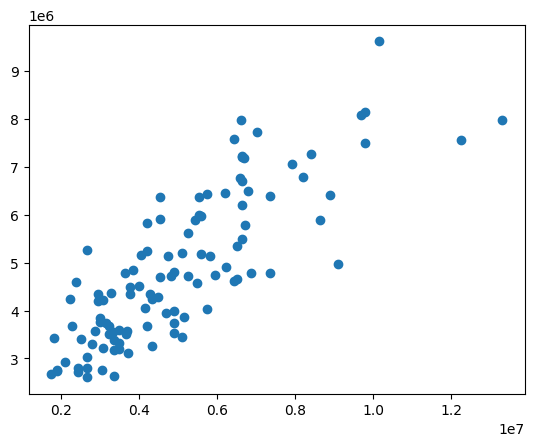

In [40]:
plt.scatter(y_test,y_predict)

Let's check Feature co.efficients

In [57]:
coef = pd.Series(linear_model.coef_, index=x.columns)
print(coef.sort_values())

furnishingstatus_unfurnished      -4.136451e+05
furnishingstatus_semi-furnished   -1.268818e+05
area                               2.359688e+02
bedrooms                           7.677870e+04
parking                            2.248419e+05
guestroom                          2.316100e+05
mainroad                           3.679199e+05
basement                           3.902512e+05
stories                            4.074766e+05
prefarea                           6.298906e+05
hotwaterheating                    6.846499e+05
airconditioning                    7.914267e+05
bathrooms                          1.094445e+06
dtype: float64


Using RandomForestRegressor

In [67]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor()
rf_model.fit(x_train,y_train)

RandomForestRegressor()

Finding r2_score,rmse,mae,mse for random forest regressor model.

In [68]:
rf_predict=rf_model.predict(x_test)
from sklearn.metrics import r2_score
print("R2_SCORE:",r2_score(y_test,rf_predict))
from sklearn.metrics import mean_absolute_error
print("MAE:",mean_absolute_error(y_test,rf_predict))
from sklearn.metrics import mean_squared_error
print("MSE:",mean_squared_error(y_test,rf_predict))
rmse=np.sqrt(mean_squared_error(y_test,rf_predict))
print("RMSE:",rmse)

R2_SCORE: 0.6202100012036746
MAE: 1016376.8978593273
MSE: 1919675227780.9053
RMSE: 1385523.4490187834


Finding the feature importance of random forest model

In [56]:
feature_coef=pd.Series(rf_model.feature_importances_,index=x.columns)
print(feature_coef.sort_values())

mainroad                           0.009551
furnishingstatus_semi-furnished    0.013455
guestroom                          0.017937
hotwaterheating                    0.018053
prefarea                           0.030383
basement                           0.033539
furnishingstatus_unfurnished       0.038360
bedrooms                           0.047115
airconditioning                    0.053603
parking                            0.056625
stories                            0.058169
bathrooms                          0.160488
area                               0.462723
dtype: float64


                      **WEEK-4 CHARTS**

Chart-1:Histogram showing distribution of house prices  
                     


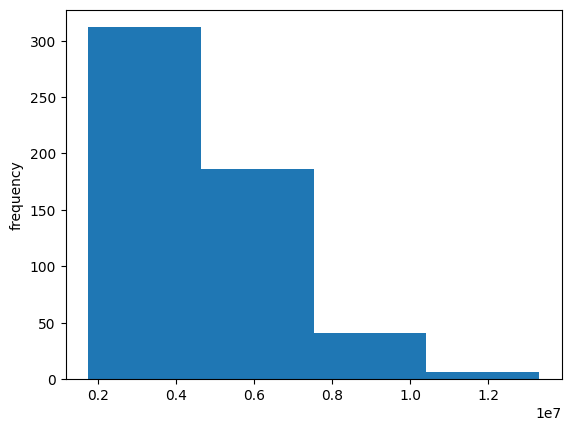

In [64]:
plt.hist(df["target"],bins=4)
plt.ylabel("frequency")
plt.show()

Chart-2:Correlation heatmap showing which features relate most strongly to price


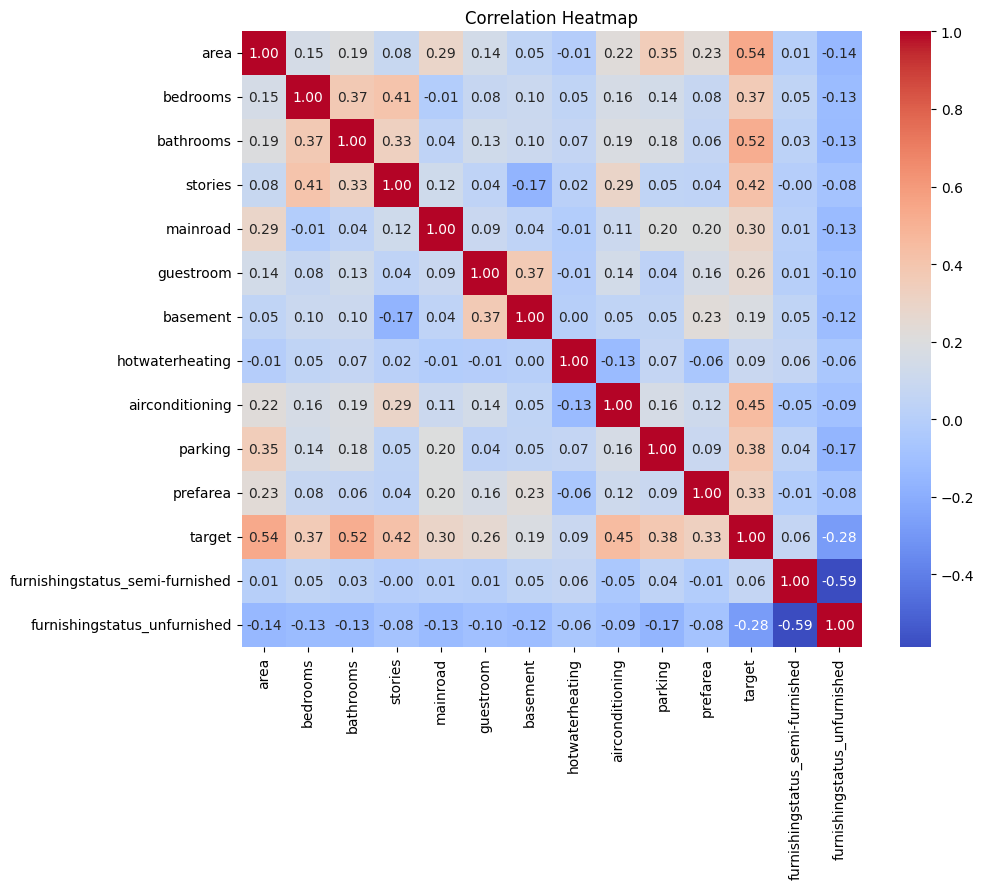

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Chart-3:Area Vs Price Scatter Plot

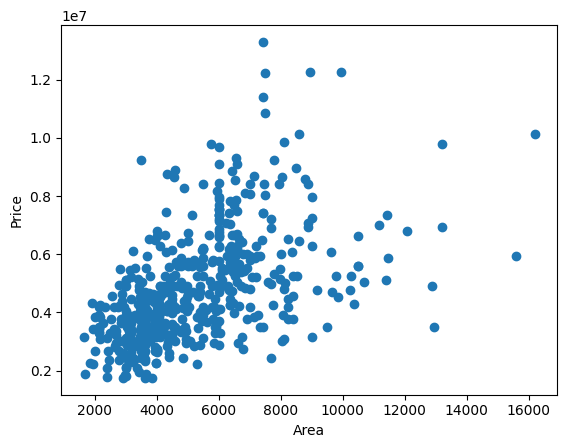

In [66]:
plt.scatter(df["area"],df["target"])
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

                    **WEEK-5 INSIGHTS AND SUMMARY**

1. Which features influence house price the most?

The features that have the strongest influence on house price are **area, number of bathrooms, bedrooms, stories, air conditioning, and main road accessibility**. Among these, **area and location-related factors have the greatest impact** on determining the price of a house.

---

2. How accurate was your model (in plain terms)?

* The **Linear Regression model** achieved an **R² score of 0.6595 (65.95%), meaning it can explain about **66% of the variation in house prices**.
* The **Random Forest Regressor** achieved an **R² score of 0.6296 (62.96%)**, explaining about **63% of the variation in house prices**.

Therefore, the **Linear Regression model performed slightly better** on this dataset.

---

3. What surprised you in the data?

* One interesting observation was that the dataset contained **no missing values and no duplicate records**, which reduced the amount of data preprocessing required and made the analysis process more straightforward.

---

4. One recommendation for a real estate business based on your findings

* Based on the analysis, **area and location-related features have the greatest impact on house prices**. Therefore, real estate businesses should prioritize properties with larger areas and good accessibility. However, factors such as the number of bedrooms, bathrooms, stories, and amenities like air conditioning should also be considered, as they contribute significantly to the overall property value.
